In [1]:
import sys
import warnings
import numpy as np
import networkx as nx
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# RDKit
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D

# Visualisation
from IPython.display import display, Image as IPImage
from PIL import Image
import io

# Pipeline modules (adjust path if needed)
# sys.path.insert(0, "/path/to/your/project")
from graph_encoders.wl import WL
from dict_learners.aksvd import AKSVD
from utils.graph_data import GraphDataLoader
from interpreter.wl_aksvd_interpreter import WLAKSVDInterpreter

warnings.filterwarnings("ignore")

In [2]:
from collections import Counter

data_loader = GraphDataLoader()
graphs, y = data_loader.nci_full_graphs, data_loader.nci_full_labels

print(f"Dataset size : {len(graphs)} graphs")
print(f"Label dist.  : {Counter(y)}")
print()

# Inspect first graph
sample_g = graphs[0]

print(f"Sample graph : {sample_g.number_of_nodes()} nodes, {sample_g.number_of_edges()} edges")

# First few nodes
print("\nFirst 5 nodes:")
for node_id, attrs in list(sample_g.nodes(data=True))[:5]:
    print(f"  Node {node_id}: {attrs}")

# First few edges
print("\nFirst 3 edges:")
for u, v, attrs in list(sample_g.edges(data=True))[:3]:
    print(f"  {u} -- {v}: {attrs}")

# Determine the attribute key and value type
sample_node = list(sample_g.nodes(data=True))[0]

print("\nSample node")
print(f"Node ID   : {sample_node[0]}")
print(f"Attributes: {sample_node[1]}")
print(f"Attr keys : {list(sample_node[1].keys())}")

Loading NCI dataset


[20:35:05] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] ERROR: Could not sanitize molecule ending on line 5976
[20:35:05] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] Explicit valence for atom # 0 Br, 1, is greater than permitted
[20:35:05] ERROR: Could not sanitize molecule ending on line 9488
[20:35:05] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[20:35:05] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] ERROR: Could not sanitize molecule ending on line 12926
[20:35:05] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] ERROR: Could not sanitize molecule ending on line 13981
[20:35:05] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[20:35:05] ERROR: Could not sanitize mol

Loaded 36937 graphs
Dataset size : 36937 graphs
Label dist.  : Counter({-1: 35203, 1: 1734})

Sample graph : 44 nodes, 47 edges

First 5 nodes:
  Node 0: {'feature': 'Cl'}
  Node 1: {'feature': 'O'}
  Node 2: {'feature': 'O'}
  Node 3: {'feature': 'O'}
  Node 4: {'feature': 'O'}

First 3 edges:
  0 -- 29: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}
  1 -- 12: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}
  1 -- 13: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}

Sample node
Node ID   : 0
Attributes: {'feature': 'Cl'}
Attr keys : ['feature']


In [3]:
print(type(graphs))
print(len(graphs))

<class 'list'>
36937


SMILES --> NetworkX Graph Converter

In [7]:
# ──────────────────────────────────────────────────────────────────────────
# Configuration — Match the node representation used in the NCI dataset
# ──────────────────────────────────────────────────────────────────────────

# The NCI graphs use the node attribute "label"
ATTR_KEY = "feature"


def _atom_feature(atom) -> str:
    """
    Convert an RDKit atom to the same representation used in the
    NCI training graphs.

    The NCI dataset stores element symbols as node features
    (e.g., 'C', 'N', 'O', 'Cl').
    """
    return atom.GetSymbol()


def smiles_to_graph(smiles: str) -> nx.Graph:
    """
    Parse a SMILES string and convert it into a NetworkX graph that
    matches the representation used during NCI training.

    Parameters
    ----------
    smiles : str
        A valid SMILES string.

    Returns
    -------
    nx.Graph
        Undirected molecular graph with:
            - node attribute: "label"
            - node value: element symbol (e.g. C, N, O, Cl)
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: '{smiles}'")

    # Uncomment ONLY if the training graphs contain explicit hydrogens.
    # From what we've inspected so far, keep this commented.
    # mol = Chem.AddHs(mol)

    g = nx.Graph()

    # Add atoms
    for atom in mol.GetAtoms():
        g.add_node(
            atom.GetIdx(),
            **{ATTR_KEY: _atom_feature(atom)}
        )

    # Add bonds
    for bond in mol.GetBonds():
        g.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx()
        )

    return g


def smiles_to_mol_and_graph(smiles: str):
    """
    Return both:
        1. RDKit Mol object
        2. NetworkX graph compatible with the WL-AKSVD pipeline
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: '{smiles}'")

    graph = smiles_to_graph(smiles)

    return mol, graph

In [8]:
graphs[0]

In [9]:
# ──────────────────────────────────────────────────────────────────────────
# Verify that the SMILES converter matches the NCI training graph format
# ──────────────────────────────────────────────────────────────────────────

test_g = smiles_to_graph("c1ccccc1")      # Benzene
nci_sample = graphs[0]

print("SMILES graph (benzene):")
print(f"  Nodes : {test_g.number_of_nodes()}")
print(f"  Edges : {test_g.number_of_edges()}")
print("  First 5 nodes:")
for node, attrs in list(test_g.nodes(data=True))[:5]:
    print(f"    {node}: {attrs}")

print("\nNCI training graph:")
print(f"  Nodes : {nci_sample.number_of_nodes()}")
print(f"  Edges : {nci_sample.number_of_edges()}")
print("  First 5 nodes:")
for node, attrs in list(nci_sample.nodes(data=True))[:5]:
    print(f"    {node}: {attrs}")

# ------------------------------------------------------------------
# Check attribute key
# ------------------------------------------------------------------
smiles_key = list(test_g.nodes(data=True))[0][1].keys()
nci_key = list(nci_sample.nodes(data=True))[0][1].keys()

print("\nAttribute Key Check")
print("-------------------")

if set(smiles_key) == set(nci_key):
    print("✅ Attribute keys match.")
else:
    print("❌ Attribute keys do NOT match.")
    print(f"SMILES : {list(smiles_key)}")
    print(f"NCI    : {list(nci_key)}")

# ------------------------------------------------------------------
# Check attribute value type
# ------------------------------------------------------------------
key = list(smiles_key)[0]

smiles_value = list(test_g.nodes(data=True))[0][1][key]
nci_value = list(nci_sample.nodes(data=True))[0][1][key]

print("\nAttribute Value Check")
print("---------------------")
print(f"SMILES : {smiles_value}")
print(f"NCI    : {nci_value}")

if type(smiles_value) == type(nci_value):
    print("✅ Attribute value types match.")
else:
    print("❌ Attribute value types differ.")

# ------------------------------------------------------------------
# Compare element representation
# ------------------------------------------------------------------
print("\nElement Representation")
print("----------------------")

print("SMILES unique labels (first 10):")
print(sorted({d[key] for _, d in test_g.nodes(data=True)})[:10])

print("\nNCI unique labels (first 10):")
print(sorted({d[key] for _, d in nci_sample.nodes(data=True)})[:10])

print("\n✅ If both graphs use element symbols (C, N, O, Cl, ...),")
print("   the converter is compatible with the training data.")

SMILES graph (benzene):
  Nodes : 6
  Edges : 6
  First 5 nodes:
    0: {'feature': 'C'}
    1: {'feature': 'C'}
    2: {'feature': 'C'}
    3: {'feature': 'C'}
    4: {'feature': 'C'}

NCI training graph:
  Nodes : 44
  Edges : 47
  First 5 nodes:
    0: {'feature': 'Cl'}
    1: {'feature': 'O'}
    2: {'feature': 'O'}
    3: {'feature': 'O'}
    4: {'feature': 'O'}

Attribute Key Check
-------------------
✅ Attribute keys match.

Attribute Value Check
---------------------
SMILES : C
NCI    : Cl
✅ Attribute value types match.

Element Representation
----------------------
SMILES unique labels (first 10):
['C']

NCI unique labels (first 10):
['C', 'Cl', 'N', 'O']

✅ If both graphs use element symbols (C, N, O, Cl, ...),
   the converter is compatible with the training data.


In [11]:
graph = smiles_to_graph(SMILES)

documents = wl.create_wl_hash([graph])
doc = documents[0]

vocab_words = {word for word, _ in wl.vocab}
matches = sum(word in vocab_words for word in doc.words)

print("Graph tokens   :", len(doc.words))
print("Vocabulary matches:", matches)

embedding = wl.generate_inferencing_embeddings([graph])

print("Non-zero features:", np.count_nonzero(embedding))
print("Feature sum:", embedding.sum())

NameError: name 'SMILES' is not defined

In [12]:
# ── Data splits ───────────────────────────────────────────────────────────
G_train, G_test, y_train, y_test = train_test_split(
    graphs, y, test_size=0.2, random_state=42
)
G_vocab_train, G_ML_train, y_vocab_train, y_ML_train = train_test_split(
    G_train, y_train, test_size=0.75, random_state=42
)

print(f"Vocab train : {len(G_vocab_train)}")
print(f"ML train    : {len(G_ML_train)}")
print(f"Test        : {len(G_test)}")

# ── WL hashing ────────────────────────────────────────────────────────────
wl = WL()
wl_embeddings_vocab = wl.generate_training_embeddings(G_vocab_train, y_vocab_train)
print(f"Vocab size  : {wl.n_vocab}")

# ── AKSVD dictionary learning ────────────────────────────────────────────
aksvd = AKSVD()
aksvd.fit(training_graph_embeddings=wl_embeddings_vocab)
print(f"Dictionary  : {aksvd._dictionary.shape}")

# ── Generate sparse codes for ML train & test ─────────────────────────────
wl_emb_ml_train = wl.generate_inferencing_embeddings(G_ML_train)
X_ML_train = aksvd.infer(wl_emb_ml_train)

wl_emb_test = wl.generate_inferencing_embeddings(G_test)
X_ML_test = aksvd.infer(wl_emb_test)

# ── Scaling ───────────────────────────────────────────────────────────────
scaler = MaxAbsScaler()
X_ML_train_scaled = scaler.fit_transform(X_ML_train)
X_ML_test_scaled = scaler.transform(X_ML_test)

Vocab train : 7387
ML train    : 22162
Test        : 7388
Selected 6690 features via adaptive selection
Vocab size  : 6690
Dictionary  : (1024, 6690)


In [ ]:
# Logistic Regression is preferred for interpretability because coef_
# gives per-atom signed attribution (unlike tree-based feature_importances_)
classifier = LogisticRegression(
    max_iter=1000,
    solver="saga",
    random_state=42,
    class_weight="balanced",
)
classifier.fit(X_ML_train_scaled, y_ML_train)

y_pred = classifier.predict(X_ML_test_scaled)
print(classification_report(y_test, y_pred))
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

          -1       0.98      0.85      0.91      7027
           1       0.19      0.69      0.30       361

    accuracy                           0.84      7388
   macro avg       0.59      0.77      0.60      7388
weighted avg       0.94      0.84      0.88      7388

Test accuracy: 0.8408


In [ ]:
LABEL_MAP = {0: "Inactive against cancer", 1: "Active against cancer"}

interpreter = WLAKSVDInterpreter(
    wl=wl,
    aksvd=aksvd,
    classifier=classifier,
    scaler=scaler,
    training_graphs=G_ML_train,
    training_labels=y_ML_train,
    training_sparse_codes=X_ML_train,   # unscaled, for cosine similarity
    label_map=LABEL_MAP,
)

print("✅ Interpreter ready.")

✅ Interpreter ready.


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def _importance_colour_map(
    node_importance: dict,
    sorted_nodes: list,
    supporting_cmap: str = "Reds",
    opposing_cmap: str = "Blues",
    floor_alpha: float = 0.15,
) -> dict:
    """
    Map each node to an RGBA tuple based on signed importance.

    Supporting nodes  → red gradient   (pushes toward predicted class)
    Opposing nodes    → blue gradient  (pushes against predicted class)

    Nodes with zero importance get a faint wash so they remain visible.
    """
    if not sorted_nodes:
        return {}

    max_abs = max(abs(s) for _, s in sorted_nodes) or 1.0
    sup_cm = cm.get_cmap(supporting_cmap)
    opp_cm = cm.get_cmap(opposing_cmap)

    colours = {}
    for node_id, score in sorted_nodes:
        intensity = abs(score) / max_abs
        # Scale into [floor_alpha, 1.0] so even low-importance atoms are visible
        mapped = floor_alpha + intensity * (1.0 - floor_alpha)

        if score >= 0:
            rgba = sup_cm(mapped)
        else:
            rgba = opp_cm(mapped)

        colours[node_id] = rgba

    return colours


def visualise_prediction(
    smiles: str,
    interpreter: "WLAKSVDInterpreter",
    top_k_atoms: int = 5,
    img_size: tuple = (600, 400),
    show_atom_indices: bool = True,
    show_percentages: bool = True,
    supporting_cmap: str = "Reds",
    opposing_cmap: str = "Blues",
) -> Image.Image:
    """
    End-to-end: SMILES → classification → node-importance → highlighted image.

    Parameters
    ----------
    smiles           : SMILES string to classify and explain.
    interpreter      : fitted WLAKSVDInterpreter.
    top_k_atoms      : number of dictionary atoms to trace.
    img_size         : (width, height) of the output image.
    show_atom_indices: annotate atoms with their index.
    show_percentages : annotate atoms with importance %.
    supporting_cmap  : matplotlib colourmap name for supporting atoms.
    opposing_cmap    : matplotlib colourmap name for opposing atoms.

    Returns
    -------
    PIL.Image.Image  — the rendered molecule with highlighting.
    """
    mol, graph = smiles_to_mol_and_graph(smiles)

    # Run interpretability
    result = interpreter.get_node_importance(graph, top_k_atoms=top_k_atoms)

    # Compute 2D coordinates for a clean layout
    AllChem.Compute2DCoords(mol)

    # Build colour map
    sorted_nodes = result["sorted_nodes"]
    colour_map = _importance_colour_map(
        result["node_importance"],
        sorted_nodes,
        supporting_cmap=supporting_cmap,
        opposing_cmap=opposing_cmap,
    )

    # Prepare RDKit highlight arguments
    highlight_atoms = list(colour_map.keys())
    highlight_atom_colours = {
        int(k): tuple(v[:3]) for k, v in colour_map.items()
    }

    # Highlight bonds connecting two highlighted atoms
    highlight_bonds = []
    highlight_bond_colours = {}
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if a1 in colour_map and a2 in colour_map:
            bid = bond.GetIdx()
            highlight_bonds.append(bid)
            # Average the colours of the two endpoint atoms
            c1 = np.array(colour_map[a1][:3])
            c2 = np.array(colour_map[a2][:3])
            highlight_bond_colours[bid] = tuple((c1 + c2) / 2)

    # Draw with the SVG renderer for crisp output
    drawer = rdMolDraw2D.MolDraw2DCairo(*img_size)
    opts = drawer.drawOptions()
    opts.useBWAtomPalette()

    if show_atom_indices:
        for atom in mol.GetAtoms():
            idx = atom.GetIdx()
            if show_percentages and idx in result["node_importance_pct"]:
                pct = result["node_importance_pct"][idx]
                atom.SetProp("atomNote", f"{pct:.1f}%")
            else:
                atom.SetProp("atomNote", str(idx))

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_atom_colours,
        highlightBonds=highlight_bonds,
        highlightBondColors=highlight_bond_colours,
    )
    drawer.FinishDrawing()

    bio = io.BytesIO(drawer.GetDrawingText())
    return Image.open(bio)


def full_analysis(
    smiles: str,
    interpreter: "WLAKSVDInterpreter",
    top_k_atoms: int = 5,
    img_size: tuple = (700, 450),
):
    """
    Full end-to-end analysis: classification, text report, and visualisation.
    """
    mol, graph = smiles_to_mol_and_graph(smiles)

    # 1. Full text report
    report = interpreter.full_report(
        graph,
        top_k_atoms=top_k_atoms,
        top_k_features_per_atom=5,
        top_k_similar=5,
    )
    print(report)

    # 2. Highlighted visualisation
    img = visualise_prediction(
        smiles,
        interpreter,
        top_k_atoms=top_k_atoms,
        img_size=img_size,
    )
    display(img)

    return img

In [ ]:
G_test[0]

In [ ]:
print(G_test[0].graph)

{}


In [ ]:
print(list(G_test[0].nodes(data=True))[:5])

[(0, {'feature': 'O'}), (1, {'feature': 'O'}), (2, {'feature': 'O'}), (3, {'feature': 'N'}), (4, {'feature': 'C'})]


In [ ]:
dir(data_loader)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_initialized',
 '_instance',
 'load_nci_balanced',
 'load_nci_full',
 'nci_full_graphs',
 'nci_full_labels']

In [ ]:
vars(data_loader).keys()

dict_keys(['nci_full_graphs', 'nci_full_labels', '_initialized'])

In [ ]:
from rdkit import Chem
import networkx as nx

print('Loading NCI1 dataset')

graphs = []
y = []
smiles_list = []

filepath = "datasets/NCI_full/1total-connect.sdf"

supplier = Chem.SDMolSupplier(filepath, removeHs=False)

for mol in supplier:
    if mol is None:
        continue

    # Convert molecule to SMILES
    smiles = Chem.MolToSmiles(mol)

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            label=atom.GetSymbol()
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
            bond_order=bond.GetBondTypeAsDouble(),
            aromatic=bond.GetIsAromatic(),
            in_ring=bond.IsInRing(),
            conjugated=bond.GetIsConjugated(),
            stereo=str(bond.GetStereo())
        )

    # Graph label
    label = int(float(mol.GetProp("value")))

    graphs.append(G)
    y.append(label)
    smiles_list.append(smiles)

print(f"Loaded {len(graphs)} graphs")
print(f"Loaded {len(smiles_list)} SMILES strings")

# Example
print(smiles_list[0])
print(y[0])

Loading NCI1 dataset


[18:41:13] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] ERROR: Could not sanitize molecule ending on line 5976
[18:41:13] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] Explicit valence for atom # 0 Br, 1, is greater than permitted
[18:41:13] ERROR: Could not sanitize molecule ending on line 9488
[18:41:13] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[18:41:13] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] ERROR: Could not sanitize molecule ending on line 12926
[18:41:13] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] ERROR: Could not sanitize molecule ending on line 13981
[18:41:13] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[18:41:13] ERROR: Could not sanitize mol

Loaded 36937 graphs
Loaded 36937 SMILES strings
COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2
1


In [ ]:
# Example
print(y[10000])
print(smiles_list[10000])

-1
N#CC1=C(N)N(c2ccccc2)C(c2ccccc2)C1(C#N)C#N


In [ ]:
mol, graph = smiles_to_mol_and_graph(SMILES)

print(graph.number_of_nodes())
print(graph.number_of_edges())
print(graph.nodes(data=True))

NameError: name 'SMILES' is not defined

In [ ]:
print(type(wl))

<class 'graph_encoders.wl.WL'>


In [ ]:
print(wl.__dict__.keys())

dict_keys(['name', 'embeddings', 'seed', 'vocab', 'graph_embeddings', 'wl_iterations', 'attributed', 'erase_base_features', 'n_vocab', 'min_features', 'class_df', 'class_counts'])


In [ ]:
print(dir(wl))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_check_graph', '_check_graphs', '_check_indexing', '_ensure_integrity', '_set_seed', 'attributed', 'calc_coefficients', 'class_counts', 'class_df', 'create_vocab', 'create_wl_hash', 'embeddings', 'erase_base_features', 'generate_inferencing_embeddings', 'generate_training_embeddings', 'graph_embeddings', 'min_features', 'n_vocab', 'name', 'seed', 'vocab', 'wl_iterations']


In [ ]:
x = wl.transform([graph])

print(x.shape)
print(np.count_nonzero(x))
print(np.sum(x))

AttributeError: 'WL' object has no attribute 'transform'

In [ ]:
embedding = wl.generate_inferencing_embeddings([graph])

print(type(embedding))
print(np.array(embedding).shape)
print(np.count_nonzero(embedding))
print(np.sum(embedding))

<class 'numpy.ndarray'>
(1, 6690)
0
0.0


In [ ]:
print(type(wl.vocab))
print(wl.vocab[:5])

<class 'list'>
[('906cec4ee868948aa03cee2550a89333', np.float64(0.06940823130060106)), ('af3e62d65d46a9f16366be9e4b1e8143', np.float64(0.06683936547622754)), ('eb5d7020ad85d702f9f4a48b72bf911e', np.float64(0.05662238011923217)), ('e3aa29b076ce0fa47e14a9d786017c85', np.float64(0.05541380565016638)), ('8db910500404fcf6f2f3bf4a86dcee9e', np.float64(0.053812030545960766))]


═════════════════════════════════════════════════════════════════
  PREDICTION   : -1
  CONFIDENCE   : 81.1%
  ACTIVE ATOMS : 0
═════════════════════════════════════════════════════════════════
  CONTRIBUTION BREAKDOWN          [S = Supporting | O = Opposing]
  Dictionary Atom            Bar                                   %
─────────────────────────────────────────────────────────────────
  Others                     ██████████████████████████████  100.0%
═════════════════════════════════════════════════════════════════

── LEVEL 1: Prediction Reasoning ─────────────────────────────────────────
  Prediction : -1  (Confidence: 81.1%)
  Atoms driving this prediction:

── LEVEL 2: Dictionary Atom Composition ───────────────────────────────────

── LEVEL 4: Similar Training Compounds ────────────────────────────────────
  #1  idx=22161  label=-1                similarity=0.0%
  #2  idx=22160  label=-1                similarity=0.0%
  #3  idx=22159  label=-1                similarity=0.0

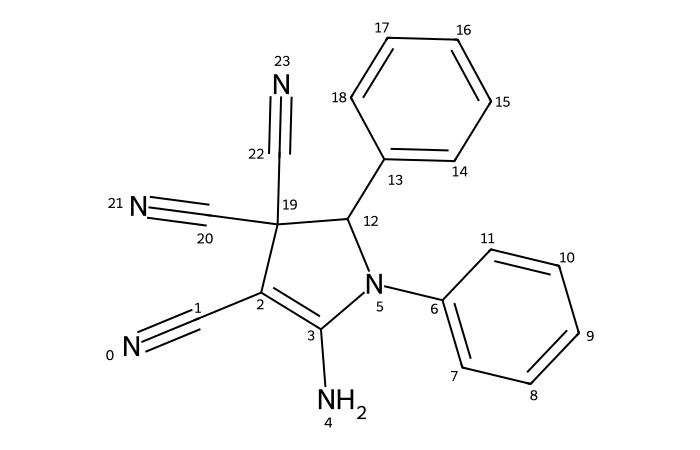

In [ ]:
# ──────────────────────────────────────────────────────────────────────────
# ⬇️  CHANGE THIS SMILES STRING TO CLASSIFY ANY MOLECULE  ⬇️
# ──────────────────────────────────────────────────────────────────────────
SMILES = "N#CC1=C(N)N(c2ccccc2)C(c2ccccc2)C1(C#N)C#N"   

img = full_analysis(SMILES, interpreter, top_k_atoms=5)

──────────────────────────────────────────────────
  Benzene (c1ccccc1)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


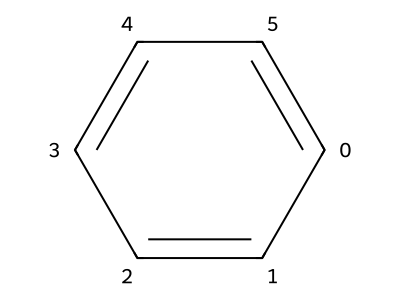

──────────────────────────────────────────────────
  Naphthalene (c1ccc2ccccc2c1)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


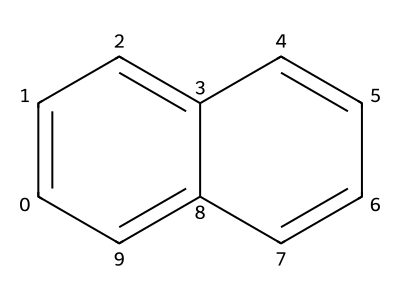

──────────────────────────────────────────────────
  Phenol (Oc1ccccc1)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


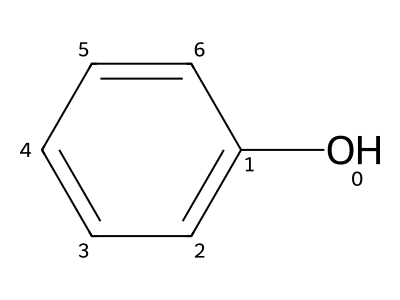

──────────────────────────────────────────────────
  Aniline (Nc1ccccc1)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


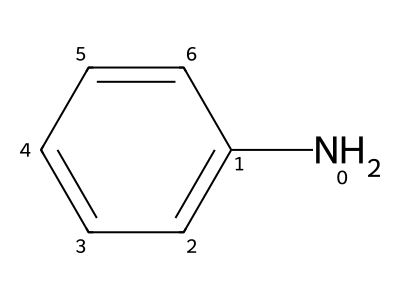

──────────────────────────────────────────────────
  Cyclohexane (C1CCCCC1)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


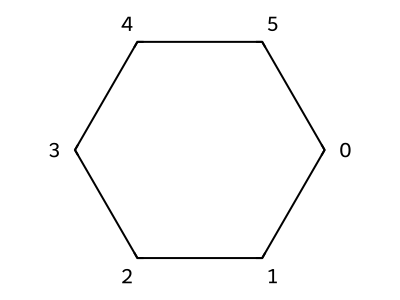

──────────────────────────────────────────────────
  Aspirin (CC(=O)Oc1ccccc1C(=O)O)
  → -1  (conf: 81.1%)
  Active dictionary atoms: 0


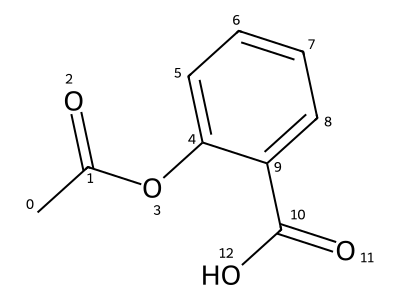


──────────────────────────────────────────────────
Summary:
  Benzene          → -1                conf=81.1%
  Naphthalene      → -1                conf=81.1%
  Phenol           → -1                conf=81.1%
  Aniline          → -1                conf=81.1%
  Cyclohexane      → -1                conf=81.1%
  Aspirin          → -1                conf=81.1%


In [ ]:
COMPOUNDS = {
    "Benzene":          "c1ccccc1",
    "Naphthalene":      "c1ccc2ccccc2c1",
    "Phenol":           "Oc1ccccc1",
    "Aniline":          "Nc1ccccc1",
    "Cyclohexane":      "C1CCCCC1",
    "Aspirin":          "CC(=O)Oc1ccccc1C(=O)O",
}

results_summary = []

for name, smi in COMPOUNDS.items():
    mol, graph = smiles_to_mol_and_graph(smi)
    explanation = interpreter.explain_prediction(graph, top_k_atoms=5)

    results_summary.append({
        "Compound": name,
        "SMILES": smi,
        "Prediction": explanation["prediction_label"],
        "Confidence": (
            f"{explanation['confidence']*100:.1f}%"
            if explanation["confidence"] is not None else "N/A"
        ),
        "Active Atoms": explanation["n_active_atoms"],
    })

    print(f"{'─'*50}")
    print(f"  {name} ({smi})")
    print(f"  → {explanation['prediction_label']}"
          f"  (conf: {explanation['confidence']*100:.1f}%)"
          if explanation['confidence'] else "")
    print(f"  Active dictionary atoms: {explanation['n_active_atoms']}")

    img = visualise_prediction(smi, interpreter, top_k_atoms=5, img_size=(400, 300))
    display(img)

print(f"\n{'─'*50}")
print("Summary:")
for r in results_summary:
    print(f"  {r['Compound']:<16} → {r['Prediction']:<16}  conf={r['Confidence']}")

In [ ]:
documents = wl.create_wl_hash([graph])

doc = documents[0]

print("Number of tokens:", len(doc.words))
print("\nFirst 20 tokens:")
print(doc.words[:20])

Number of tokens: 48

First 20 tokens:
['457cc1e12c19efc424baffb9f18f3a18', '87f7fec72a5798206428e948498c57f8', '0f8326cabb91581c0714bbd8991c8453', '76bafae5da9520f195701312c330ff5a', 'cad7ab08620117fc3658c7886380ddd7', '6d99bd3c21805e6ea6730118e1088363', 'a6641d01a607bac8c731b6fde47cc36e', 'bf8e01f8c22a0f74274cbecb243e9f84', '457cc1e12c19efc424baffb9f18f3a18', '131fac7aa356da08285227f0ff1ac683', '635220252feb8b93f8b184c5b3be3d52', '2da8c0f53803b1057554ea15ccdd1d22', '7f202e8f194913d01711c14acf7c37ad', '4da9eb2f0b6814f98efeaa4fa638cd73', '4afaa9f128ce16a4cb35d7d36b97ac5a', 'd7bb20ec643a838c6c8167690076b2d9', '4afaa9f128ce16a4cb35d7d36b97ac5a', '8a8270c609a0ec3c7272701fc894c56a', '4afaa9f128ce16a4cb35d7d36b97ac5a', '8a8270c609a0ec3c7272701fc894c56a']


In [ ]:
vocab_words = set(word for word, _ in wl.vocab)

matches = [w for w in doc.words if w in vocab_words]

print("Vocabulary size :", len(vocab_words))
print("Graph tokens    :", len(doc.words))
print("Matched tokens  :", len(matches))

print("\nMatched examples:")
print(matches[:20])

Vocabulary size : 6690
Graph tokens    : 48
Matched tokens  : 0

Matched examples:
[]


In [ ]:
print("Training graph")
print("Nodes :", graphs[0].number_of_nodes())
print("Edges :", graphs[0].number_of_edges())
print(list(graphs[0].nodes(data=True))[:10])

print()

print("Inference graph")
print("Nodes :", graph.number_of_nodes())
print("Edges :", graph.number_of_edges())
print(list(graph.nodes(data=True))[:10])

Training graph
Nodes : 44
Edges : 47
[(0, {'label': 'Cl'}), (1, {'label': 'O'}), (2, {'label': 'O'}), (3, {'label': 'O'}), (4, {'label': 'O'}), (5, {'label': 'O'}), (6, {'label': 'O'}), (7, {'label': 'O'}), (8, {'label': 'O'}), (9, {'label': 'O'})]

Inference graph
Nodes : 24
Edges : 50
[(0, {'feature': '7'}), (1, {'feature': '6'}), (2, {'feature': '6'}), (3, {'feature': '6'}), (4, {'feature': '7'}), (5, {'feature': '7'}), (6, {'feature': '6'}), (7, {'feature': '6'}), (8, {'feature': '6'}), (9, {'feature': '6'})]
